<a href="https://colab.research.google.com/github/faizhuda/daming-kelompok-7/blob/main/Project%20Daming%20Kelompok%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Kelompok 7 Daming
Prediksi AQI (Air Quality Index) menggunakan data sensor multi-polutan dari kota-kota di Bangladesh

- Steven Lie Wibowo - G6401231021
- Tristian Yosa - G6401231122
- Faiz Naufal Huda - G6401231124
- Daffa Naufal Mumtaz - G6401231168

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Setting Global
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2. Load Dataset

In [ ]:
# Google Drive
file_id = "1I7dtUfl3owj8kdwwwezEXtMBF2627_gk"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
print(f'Ukuran Dataset: {df.shape[0]:,} baris × {df.shape[1]} kolom')

Ukuran Dataset: 1,048,551 baris × 13 kolom


In [ ]:
df.head()

=== 5 Baris Pertama ===


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0000,16.7000,252.0000,NaN,18.6000,5.2000,13.0000,50.0000
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5000,12.3000,249.0000,NaN,18.5000,5.7000,19.0000,50.0000
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1000,10.9000,244.0000,NaN,18.4000,6.5000,27.0000,51.0000
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4000,10.3000,233.0000,NaN,17.2000,6.9000,39.0000,51.0000
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8000,11.3000,217.0000,NaN,14.8000,6.2000,51.0000,51.0000


In [ ]:
df.tail()

=== 5 Baris Terakhir ===


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
1048546,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T10:00,13.5000,8.2000,145.0000,NaN,1.5000,0.9000,69.0000,52.0000
1048547,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T11:00,14.0000,8.6000,157.0000,NaN,2.5000,1.1000,65.0000,51.0000
1048548,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T12:00,19.4000,12.1000,188.0000,NaN,4.6000,1.3000,55.0000,51.0000
1048549,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T13:00,22.2000,13.9000,203.0000,NaN,4.9000,1.4000,53.0000,50.0000
1048550,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T14:00,24.0000,15.1000,224.0000,NaN,5.3000,1.6000,51.0000,49.0000


In [ ]:
df.info()

Informasi Kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048551 entries, 0 to 1048550
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   city_id           1048551 non-null  int64  
 1   city_name         1048551 non-null  object 
 2   lat               1048551 non-null  float64
 3   lon               1048551 non-null  float64
 4   datetime          1048551 non-null  object 
 5   pm10              1048551 non-null  float64
 6   pm2_5             1048551 non-null  float64
 7   carbon_monoxide   1048551 non-null  float64
 8   carbon_dioxide    274224 non-null   float64
 9   nitrogen_dioxide  1048551 non-null  float64
 10  sulphur_dioxide   1048551 non-null  float64
 11  ozone             1048551 non-null  float64
 12  aqi               1047855 non-null  float64
dtypes: float64(10), int64(1), object(2)
memory usage: 104.0+ MB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [ ]:
# Kolom numerik
pollutant_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide',
                  'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']

desc = df[pollutant_cols].describe().T
desc['skewness'] = df[pollutant_cols].apply(lambda x: skew(x.dropna()))
desc['kurtosis'] = df[pollutant_cols].apply(lambda x: kurtosis(x.dropna()))
desc['missing']  = df[pollutant_cols].isnull().sum()
desc['missing%'] = (df[pollutant_cols].isnull().mean() * 100).round(2)
desc.style.background_gradient(cmap='YlOrRd', subset=['missing%', 'skewness'])

=== Statistik Deskriptif Fitur Polutan ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing,missing%
pm10,1048551.000000,74.973502,67.445483,0.200000,26.300000,56.100000,99.900000,787.900000,1.815840,4.029413,0,0.000000
pm2_5,1048551.000000,50.676192,41.860722,0.100000,19.000000,39.900000,69.600000,551.300000,1.546443,3.000944,0,0.000000
carbon_monoxide,1048551.000000,323.518705,280.412368,0.100000,155.000000,272.000000,451.000000,5084.000000,1.931625,10.251043,0,0.000000
carbon_dioxide,274224.000000,456.900698,20.958356,408.000000,444.000000,452.000000,464.000000,740.000000,2.176907,9.323056,774327,73.850000
nitrogen_dioxide,1048551.000000,16.781396,17.349888,-0.100000,4.400000,10.700000,24.400000,178.000000,2.050807,6.376468,0,0.000000
sulphur_dioxide,1048551.000000,9.784067,9.302039,0.000000,2.900000,6.600000,14.200000,172.400000,2.007330,9.948281,0,0.000000
ozone,1048551.000000,73.780800,41.042318,-3.000000,45.000000,64.000000,94.000000,328.000000,1.012571,0.804941,0,0.000000
aqi,1047855.000000,115.075078,52.627946,9.000000,68.000000,117.000000,157.235496,299.599600,0.153498,-0.611164,696,0.070000


### 3.2 Missing Value Analysis

=== Kolom dengan Missing Value ===
                Missing Count  Missing (%)
carbon_dioxide         774327      73.8500
aqi                       696       0.0700


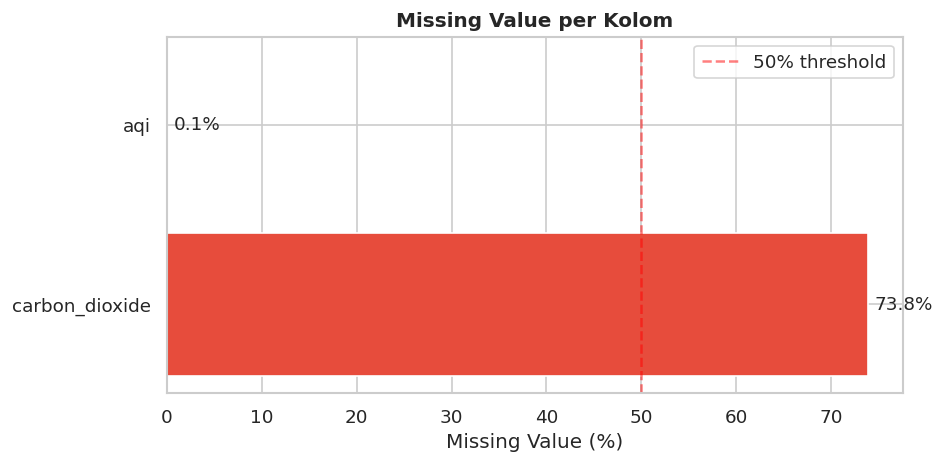

In [ ]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)' : (df.isnull().mean() * 100).round(2)
}).sort_values('Missing (%)', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df.to_string())

# Chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df['Missing (%)'],
               color=['#e74c3c' if v > 50 else '#f39c12' for v in missing_df['Missing (%)']])
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlabel('Missing Value (%)')
ax.set_title('Missing Value per Kolom', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Distribusi Kota & Cakupan Geografis

In [ ]:
city_info = df.groupby(['city_id', 'city_name', 'lat', 'lon']).size().reset_index(name='record_count')
print(f'Jumlah kota unik : {city_info.shape[0]}')
print(f'Total record     : {df.shape[0]:,}')
print()
print('Distribusi Record per Kota')
print(city_info.sort_values('record_count', ascending=False).to_string(index=False))

Jumlah kota unik : 30
Total record     : 1,048,551

=== Distribusi Record per Kota ===
 city_id           city_name     lat     lon  record_count
 1185241               Dhaka 23.7104 90.4074        227016
 1185100               Dohār 23.5931 90.1425         28992
 1185186             Comilla 23.4619 91.1850         28992
 1185218           Gafargaon 24.4320 90.5585         28992
 1185224                Feni 23.0144 91.3966         28992
 1185247            Chilmāri 25.5561 89.6710         28992
 1185262           Bherāmāra 24.0245 88.9923         28992
 1185249        Chhāgalnāiya 23.0248 91.5109         28992
 1185254             Chhātak 25.0385 91.6696         28992
 1185260 Bhātpāra Abhaynagar 23.0147 89.4394         28992
 1185270           Bāndarban 22.1953 92.2195         28992
 1185263       Bhairab Bāzār 24.0524 90.9764         28992
 1185274          Baniachang 24.5186 91.3579         28992
 1185276            Bājitpur 24.2162 90.9500         28992
 1336134         Cox’s Bāzār

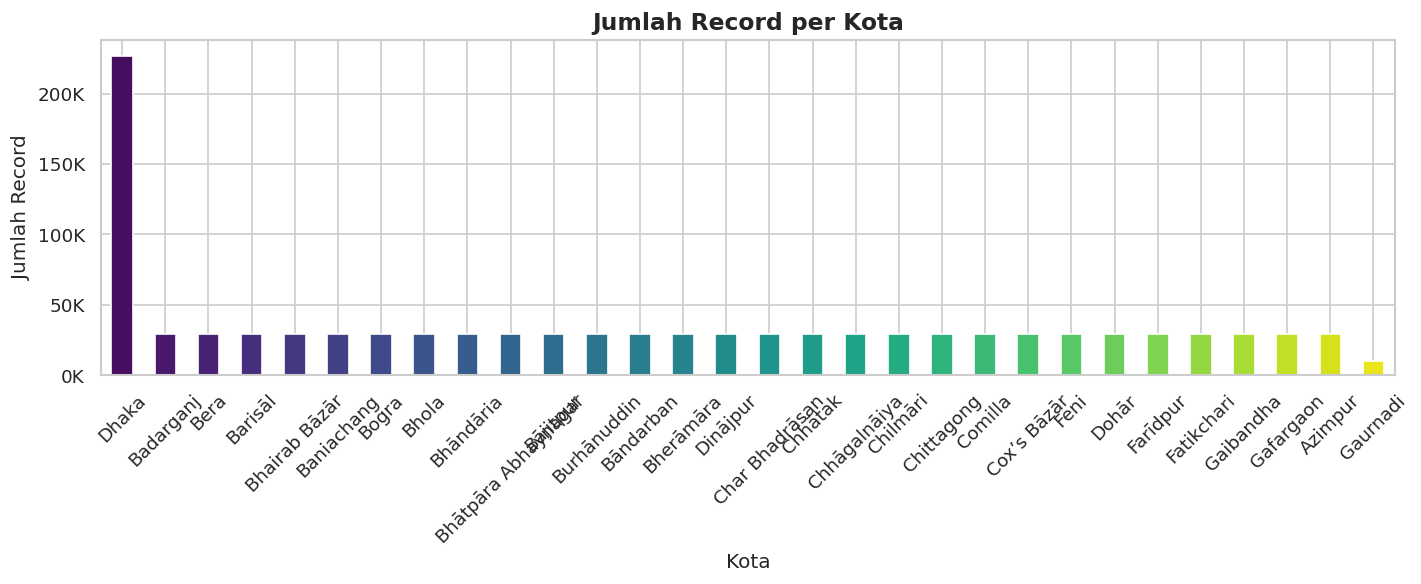

In [ ]:
# Bar chart record per kota
city_counts = df['city_name'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
city_counts.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(city_counts)), edgecolor='white')
ax.set_title('Jumlah Record per Kota', fontweight='bold', fontsize=14)
ax.set_xlabel('Kota')
ax.set_ylabel('Jumlah Record')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Analisis Time Range

=== Rentang Waktu Dataset ===
Dari  : 2000-01-01 00:00:00
Sampai: 2025-11-23 23:00:00
Durasi: 9458 hari


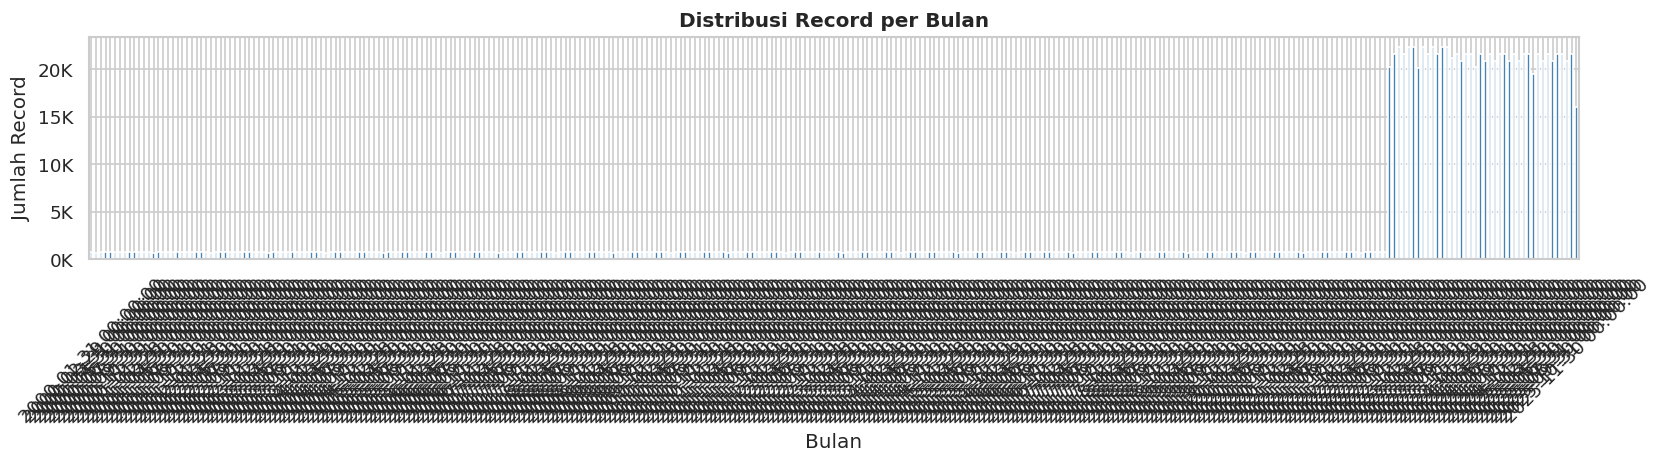

In [ ]:
# Parse datetime untuk analisis
df_dt = df.copy()
df_dt['datetime'] = pd.to_datetime(df_dt['datetime'])

print('Rentang Waktu Dataset')
print(f"Dari  : {df_dt['datetime'].min()}")
print(f"Sampai: {df_dt['datetime'].max()}")
print(f"Durasi: {(df_dt['datetime'].max() - df_dt['datetime'].min()).days} hari")

# Distribusi per bulan
monthly_counts = df_dt.set_index('datetime').resample('ME').size()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, kind='bar', color='steelblue', edgecolor='white')
ax.set_title('Distribusi Record per Bulan', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Record')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Distribusi Fitur Polutan

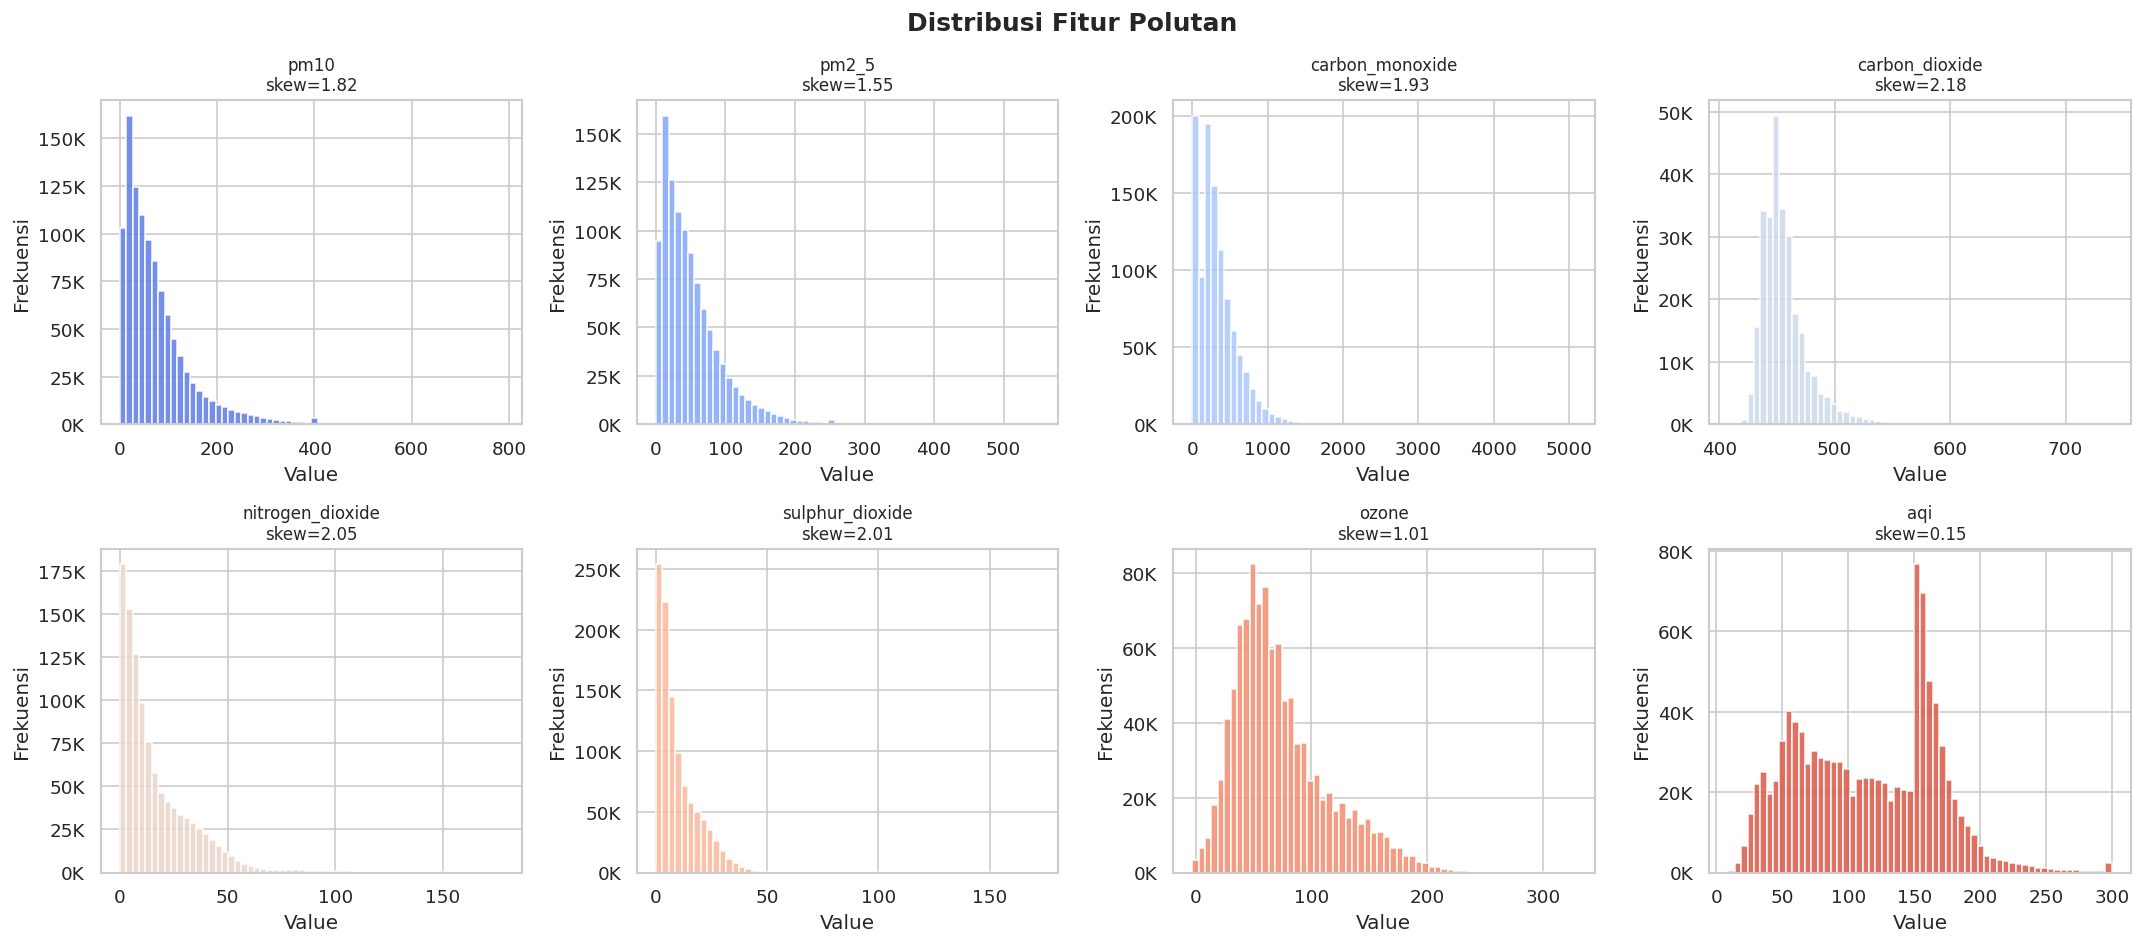

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette('coolwarm', 8)
for i, col in enumerate(pollutant_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\nskew={skew(data):.2f}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frekuensi')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Distribusi Fitur Polutan', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

### 3.6 Deteksi Nilai Negatif (Physical Bounds Check)

In [ ]:
print('Nilai Negatif per Kolom Polutan')
for col in pollutant_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'  ⚠️  {col:20s}: {neg_count:,} nilai negatif ({neg_count/len(df)*100:.3f}%)')
    else:
        print(f'  ✅  {col:20s}: tidak ada nilai negatif')

=== Nilai Negatif per Kolom Polutan ===
  ✅  pm10                : tidak ada nilai negatif
  ✅  pm2_5               : tidak ada nilai negatif
  ✅  carbon_monoxide     : tidak ada nilai negatif
  ✅  carbon_dioxide      : tidak ada nilai negatif
  ⚠️  nitrogen_dioxide    : 1 nilai negatif (0.000%)
  ✅  sulphur_dioxide     : tidak ada nilai negatif
  ⚠️  ozone               : 11 nilai negatif (0.001%)
  ✅  aqi                 : tidak ada nilai negatif


### 3.7 Outlier Detection (IQR Method)

In [ ]:
print('Deteksi Outlier (IQR Method)')
outlier_summary = {}
for col in pollutant_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Q1': q1, 'Q3': q3, 'IQR': iqr,
                            'Lower': lower, 'Upper': upper, 'Outliers': n_out,
                            'Outlier%': round(n_out/df[col].notna().sum()*100, 3)}
out_df = pd.DataFrame(outlier_summary).T
print(out_df[['Lower', 'Upper', 'Outliers', 'Outlier%']].to_string())

=== Deteksi Outlier (IQR Method) ===
                     Lower     Upper   Outliers  Outlier%
pm10             -194.5000  320.7000 10987.0000    1.0480
pm2_5            -132.8000  221.4000  5213.0000    0.4970
carbon_monoxide  -733.0000 1339.0000  6439.0000    0.6140
carbon_dioxide    384.0000  524.0000  3959.0000    1.4440
nitrogen_dioxide  -55.6000   84.4000  9611.0000    0.9170
sulphur_dioxide   -31.0000   48.1000  2398.0000    0.2290
ozone            -102.0000  241.0000   583.0000    0.0560
aqi              -199.7065  424.9420     0.0000    0.0000


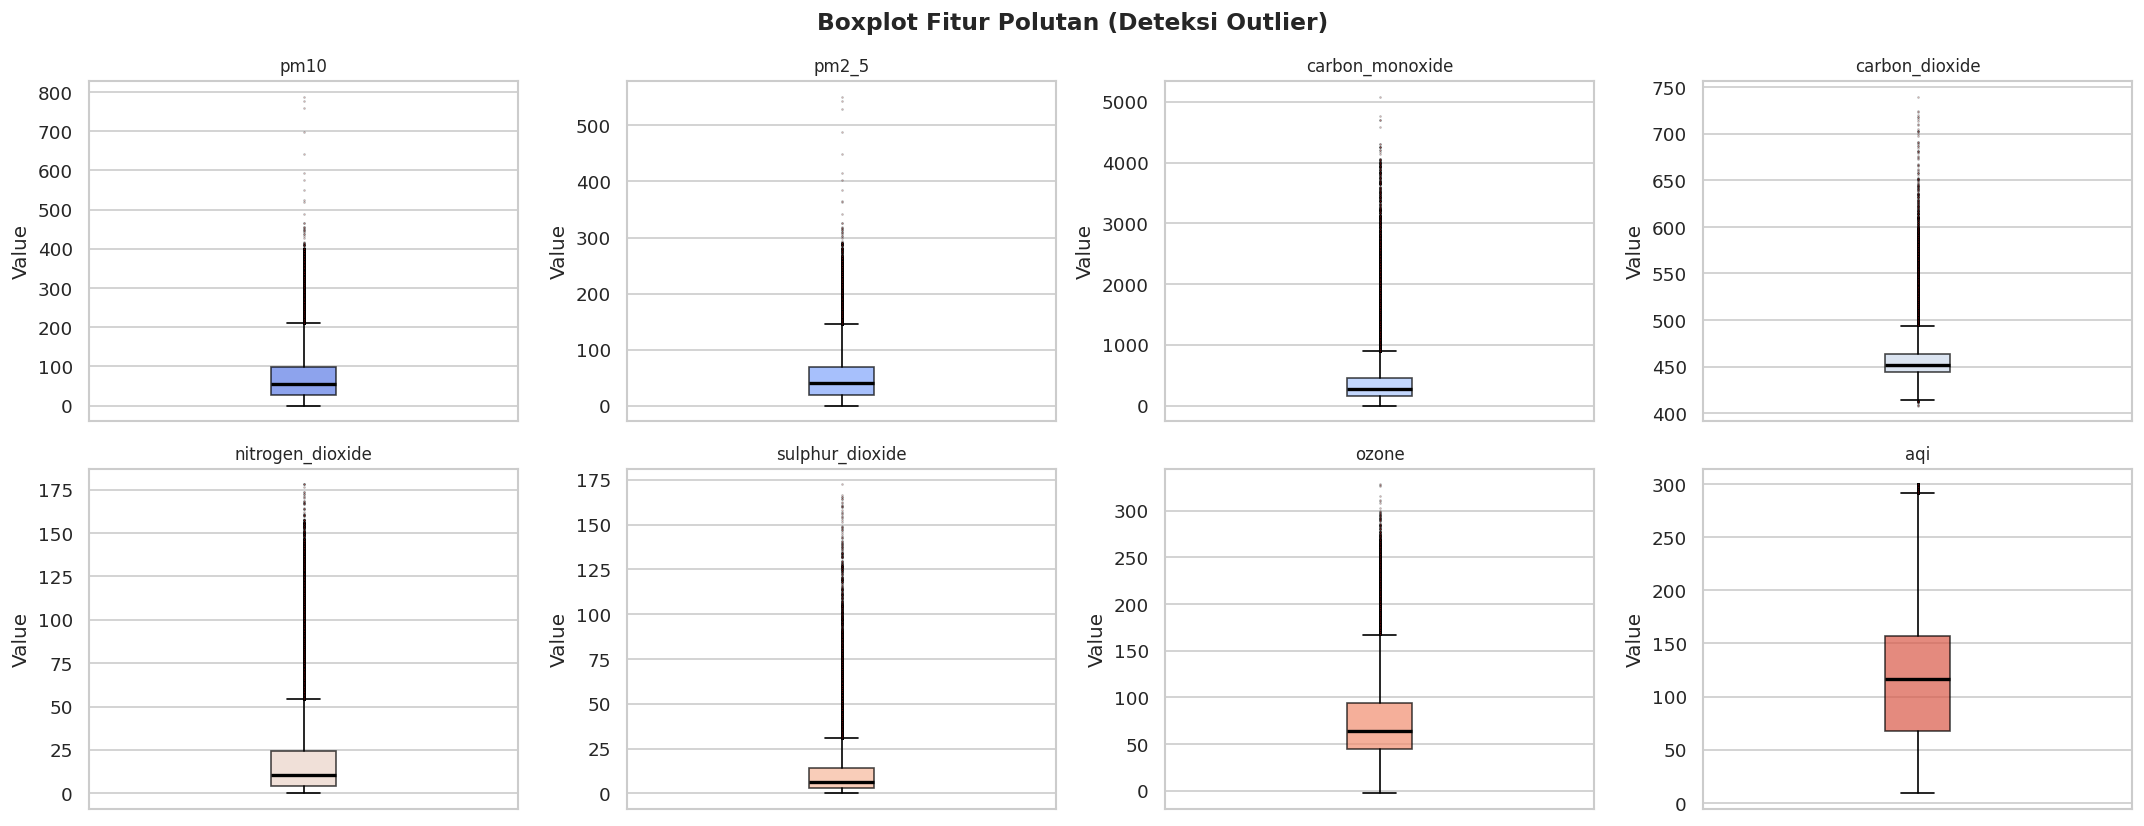

In [ ]:
# Boxplot per polutan
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markerfacecolor='red', markersize=1, alpha=0.3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

fig.suptitle('Boxplot Fitur Polutan (Deteksi Outlier)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 3.8 Korelasi Antar Fitur

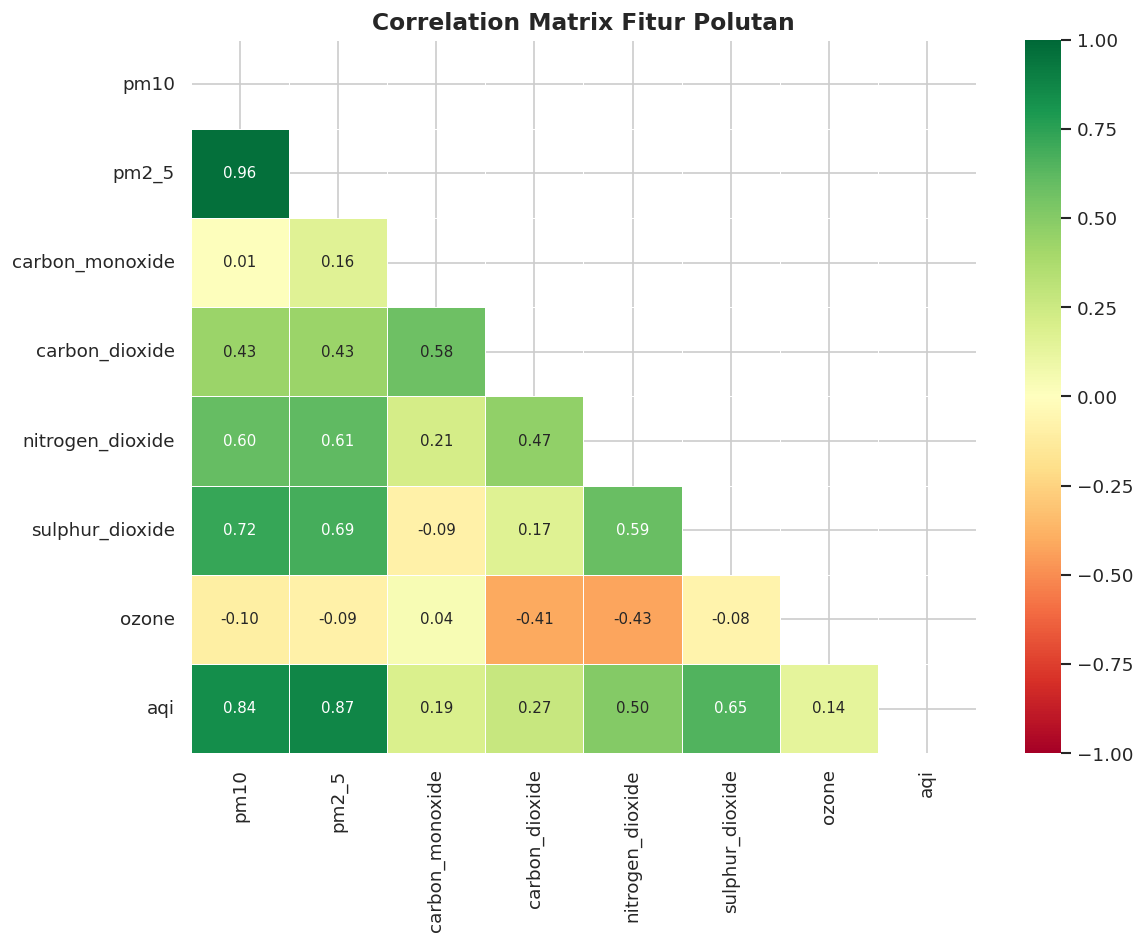


=== Korelasi dengan Target (AQI) ===
aqi                1.0000
pm2_5              0.8712
pm10               0.8387
sulphur_dioxide    0.6540
nitrogen_dioxide   0.5016
carbon_dioxide     0.2668
carbon_monoxide    0.1877
ozone              0.1375


In [ ]:
corr_matrix = df[pollutant_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # sembunyikan atas diagonal
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix Fitur Polutan', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi dengan target AQI
print('\nKorelasi dengan Target (AQI)')
aqi_corr = df[pollutant_cols].corr()['aqi'].sort_values(ascending=False)
print(aqi_corr.to_string())

### 3.9 Tren AQI per Kota (Time Series)

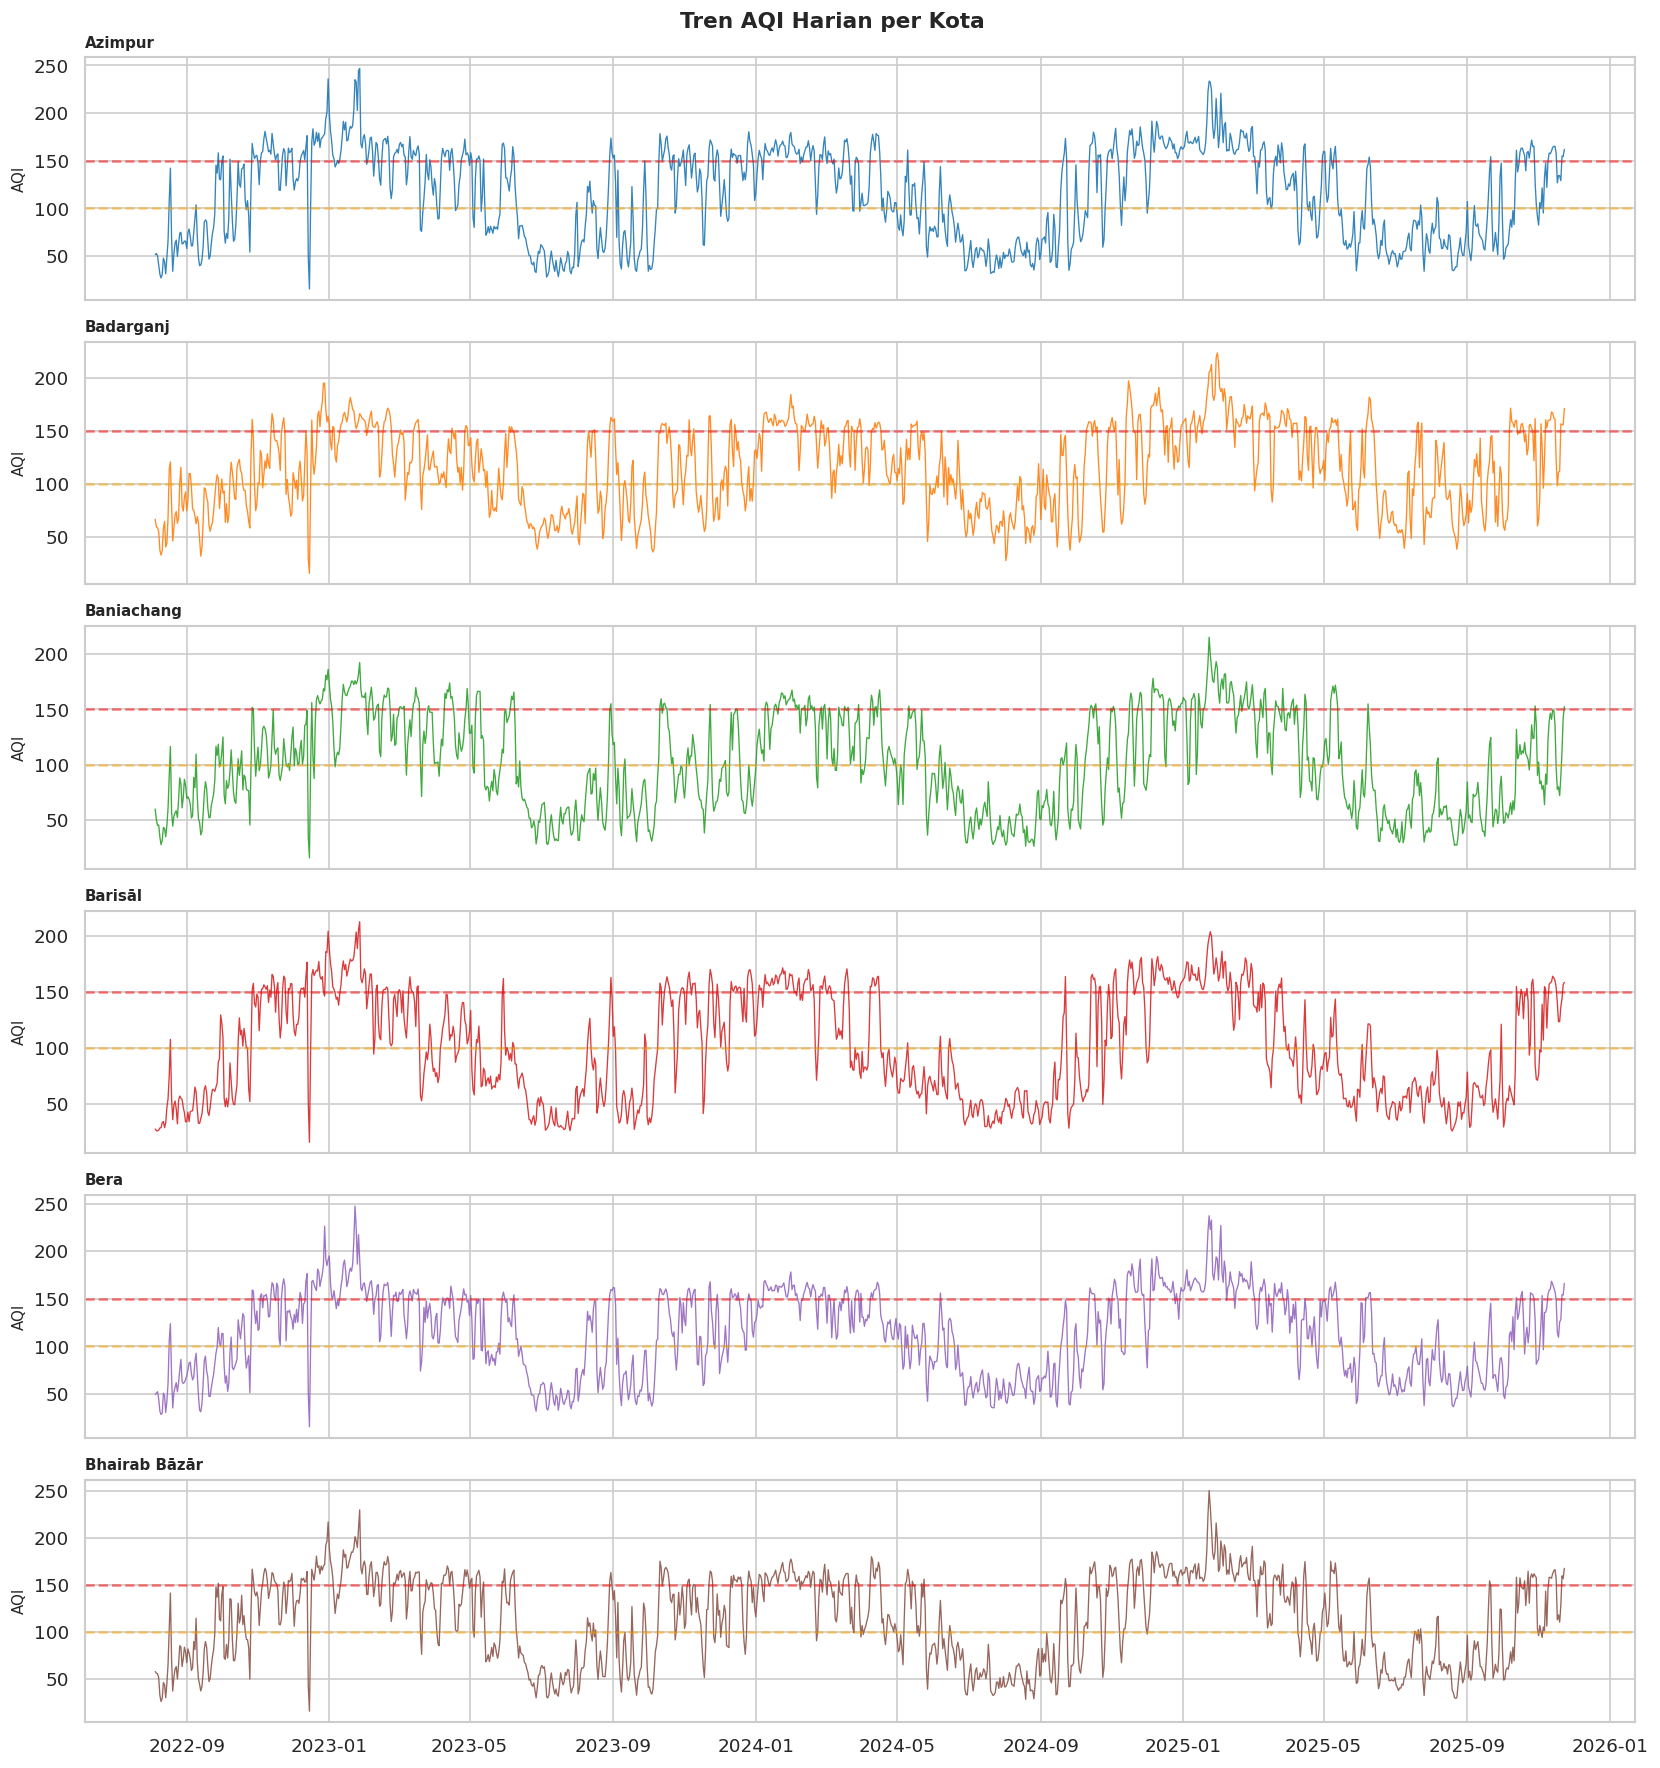

In [ ]:
df_ts = df_dt.copy()
df_ts = df_ts.set_index('datetime')

# Rata-rata AQI harian per kota
daily_aqi = df_ts.groupby('city_name')['aqi'].resample('D').mean().reset_index()
cities = daily_aqi['city_name'].unique()[:6]
fig, axes = plt.subplots(len(cities), 1, figsize=(14, len(cities) * 2.5), sharex=True)

palette = sns.color_palette('tab10', len(cities))
for i, city in enumerate(cities):
    data_city = daily_aqi[daily_aqi['city_name'] == city]
    axes[i].plot(data_city['datetime'], data_city['aqi'],
                 color=palette[i], linewidth=0.8, alpha=0.9)
    axes[i].set_ylabel('AQI', fontsize=9)
    axes[i].set_title(city, fontsize=9, loc='left', fontweight='bold')
    axes[i].axhline(100, color='orange', linestyle='--', alpha=0.5)
    axes[i].axhline(150, color='red', linestyle='--', alpha=0.5)

fig.suptitle('Tren AQI Harian per Kota', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 3.10 Pola Jam & Musiman (Hourly & Monthly Pattern)

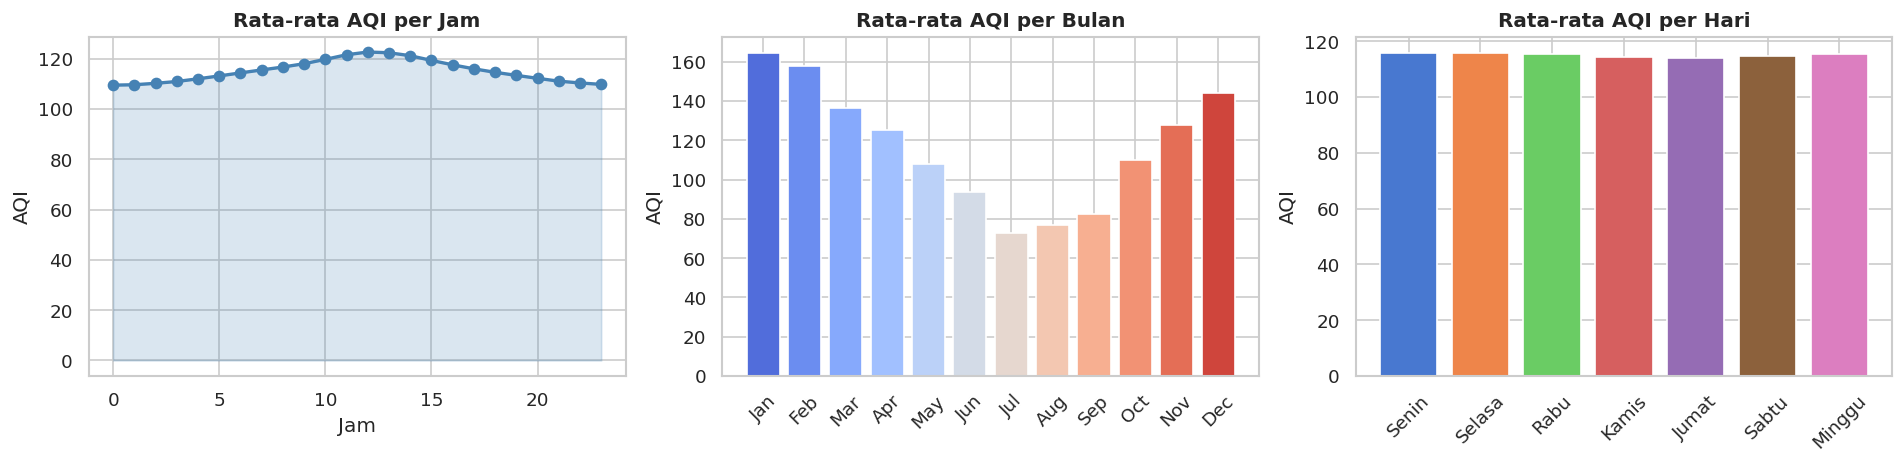

In [ ]:
df_ts2 = df_dt.copy()
df_ts2['hour']  = df_ts2['datetime'].dt.hour
df_ts2['month'] = df_ts2['datetime'].dt.month
df_ts2['dow']   = df_ts2['datetime'].dt.dayofweek  # 0=Senin

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pola per jam
hourly = df_ts2.groupby('hour')['aqi'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0].set_title('Rata-rata AQI per Jam', fontweight='bold')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('AQI')

# Pola per bulan
monthly = df_ts2.groupby('month')['aqi'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color=sns.color_palette('coolwarm', 12), edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('Rata-rata AQI per Bulan', fontweight='bold')
axes[1].set_ylabel('AQI')

# Pola per hari dalam seminggu
dow = df_ts2.groupby('dow')['aqi'].mean()
day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
axes[2].bar(range(7), dow.values, color=sns.color_palette('muted', 7), edgecolor='white')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(day_names, rotation=45)
axes[2].set_title('Rata-rata AQI per Hari', fontweight='bold')
axes[2].set_ylabel('AQI')

plt.tight_layout()
plt.show()

### 3.11 Distribusi Kategori AQI

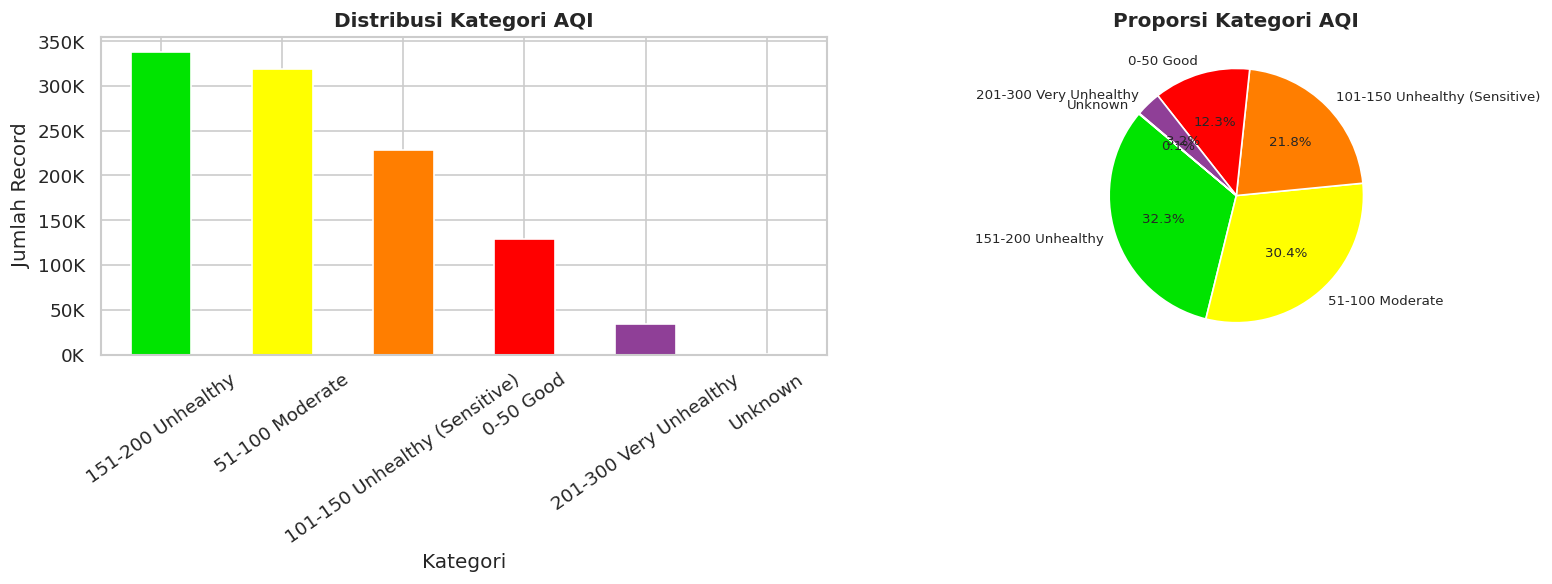


=== Distribusi Kategori AQI ===
aqi_category
151-200 Unhealthy                338240
51-100 Moderate                  318798
101-150 Unhealthy (Sensitive)    228281
0-50 Good                        128822
201-300 Very Unhealthy            33714
Unknown                             696


In [ ]:
def aqi_category(aqi):
    if pd.isna(aqi):   return 'Unknown'
    elif aqi <= 50:    return '0-50 Good'
    elif aqi <= 100:   return '51-100 Moderate'
    elif aqi <= 150:   return '101-150 Unhealthy (Sensitive)'
    elif aqi <= 200:   return '151-200 Unhealthy'
    elif aqi <= 300:   return '201-300 Very Unhealthy'
    else:              return '301+ Hazardous'

df['aqi_category'] = df['aqi'].apply(aqi_category)
cat_counts = df['aqi_category'].value_counts()

aqi_colors = ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97','#7e0023','#cccccc']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts.plot(kind='bar', ax=axes[0], color=aqi_colors[:len(cat_counts)], edgecolor='white')
axes[0].set_title('Distribusi Kategori AQI', fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Record')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].pie(cat_counts.values, labels=cat_counts.index, colors=aqi_colors[:len(cat_counts)],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Proporsi Kategori AQI', fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribusi Kategori AQI')
print(cat_counts.to_string())


## 4. Data Cleaning

### 4.1 Backup & Copy Working DataFrame

In [ ]:
df_raw = df.drop(columns=['aqi_category']).copy()  # simpan raw
df_clean = df.drop(columns=['aqi_category']).copy()  # working copy

print(f'Shape awal: {df_clean.shape}')

Shape awal: (1048551, 13)


### 4.2 Parsing Datetime & Sorting

In [ ]:
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])

# Sort berdasarkan kota dan waktu — penting untuk time-series imputation
df_clean = df_clean.sort_values(['city_id', 'datetime']).reset_index(drop=True)

print('✅ Datetime berhasil diparsing dan data diurutkan')
print(f'   Dtype datetime: {df_clean["datetime"].dtype}')
print(f'   Range: {df_clean["datetime"].min()} → {df_clean["datetime"].max()}')

✅ Datetime berhasil diparsing dan data diurutkan
   Dtype datetime: datetime64[ns]
   Range: 2000-01-01 00:00:00 → 2025-11-23 23:00:00


### 4.3 Hapus Duplikasi

In [ ]:
n_before = df_clean.shape[0]

# Duplikat sejati: city_id + datetime sama
df_clean = df_clean.drop_duplicates(subset=['city_id', 'datetime'], keep='first')

n_after = df_clean.shape[0]
print(f'✅ Duplikasi dihapus: {n_before - n_after:,} baris')
print(f'   Shape setelah: {df_clean.shape}')

✅ Duplikasi dihapus: 0 baris
   Shape setelah: (1048551, 13)


### 4.4 Penanganan Nilai Negatif (Physical Bounds)

In [ ]:
# Semua polutan tidak bisa negatif secara fisik
# Strategi: ganti dengan NaN, lalu akan diimputasi bersama missing values

neg_report = {}
for col in pollutant_cols:
    mask = df_clean[col] < 0
    n_neg = mask.sum()
    if n_neg > 0:
        df_clean.loc[mask, col] = np.nan
        neg_report[col] = n_neg

if neg_report:
    print('⚠️  Nilai negatif dikonversi ke NaN:')
    for col, n in neg_report.items():
        print(f'   {col}: {n:,} nilai')
else:
    print('✅ Tidak ada nilai negatif ditemukan')

⚠️  Nilai negatif dikonversi ke NaN:
   nitrogen_dioxide: 1 nilai
   ozone: 11 nilai


### 4.5 Penanganan Outlier (Winsorizing per Kota)

In [ ]:
# Winsorizing per kota menggunakan percentile 1% dan 99%
# Kenapa per kota? Karena karakteristik polusi bisa berbeda antar kota
# Kenapa 1-99? Mempertahankan variasi alami, hanya trim ekstrem yang tidak masuk akal

def winsorize_group(group, cols, lower=0.01, upper=0.99):
    for col in cols:
        lo = group[col].quantile(lower)
        hi = group[col].quantile(upper)
        group[col] = group[col].clip(lower=lo, upper=hi)
    return group

# Kolom yang perlu di-winsorize (exclude target sementara)
feature_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide',
                'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

df_clean = df_clean.groupby('city_name', group_keys=False).apply(
    lambda g: winsorize_group(g.copy(), feature_cols)
)

print('✅ Winsorizing selesai (1%-99% per kota)')
print(f'   Shape: {df_clean.shape}')

✅ Winsorizing selesai (1%-99% per kota)
   Shape: (1048551, 13)


### 4.6 Penanganan Missing Value

In [ ]:
print('=== Status Missing Value Sebelum Imputasi ===')
mv = df_clean[pollutant_cols].isnull().sum()
mv_pct = (df_clean[pollutant_cols].isnull().mean() * 100).round(2)
print(pd.DataFrame({'Missing': mv, 'Missing%': mv_pct}).to_string())

=== Status Missing Value Sebelum Imputasi ===
                  Missing  Missing%
pm10                    0    0.0000
pm2_5                   0    0.0000
carbon_monoxide         0    0.0000
carbon_dioxide     774327   73.8500
nitrogen_dioxide        1    0.0000
sulphur_dioxide         0    0.0000
ozone                  11    0.0000
aqi                   696    0.0700


In [ ]:
# === STRATEGI IMPUTASI ===
# carbon_dioxide: missing >74% → DROP kolom (tidak ada informasi cukup)
# aqi: missing ~0.07% (target) → drop baris tersebut (kecil, aman)
# fitur lain: interpolasi linear per kota (time-series aware)

# Step 1: Drop carbon_dioxide (terlalu banyak missing)
CO2_MISSING_THRESHOLD = 50  # persen
cols_to_drop = [c for c in pollutant_cols
                if (df_clean[c].isnull().mean() * 100) > CO2_MISSING_THRESHOLD
                and c != 'aqi']

print(f'Kolom yang akan di-drop (>{CO2_MISSING_THRESHOLD}% missing): {cols_to_drop}')
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'✅ Shape setelah drop: {df_clean.shape}')

Kolom yang akan di-drop (>50% missing): ['carbon_dioxide']
✅ Shape setelah drop: (1048551, 12)


In [ ]:
# Step 2: Drop baris di mana AQI (target) missing
n_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['aqi'])
print(f'✅ Baris dengan AQI missing dihapus: {n_before - df_clean.shape[0]:,} baris')
print(f'   Shape: {df_clean.shape}')

✅ Baris dengan AQI missing dihapus: 696 baris
   Shape: (1047855, 12)


In [ ]:
# Step 3: Interpolasi linear per kota untuk fitur polutan
# Interpolasi linear cocok untuk time-series sensor yang memiliki continuity

remaining_features = [c for c in ['pm10', 'pm2_5', 'carbon_monoxide',
                                    'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
                       if c in df_clean.columns]

def interpolate_group(group):
    for col in remaining_features:
        # Interpolasi linear, kemudian fill sisa (ujung series) dengan forward/backward fill
        group[col] = group[col].interpolate(method='linear', limit_direction='both')
        group[col] = group[col].fillna(method='bfill').fillna(method='ffill')
    return group

df_clean = df_clean.groupby('city_name', group_keys=False).apply(interpolate_group)

# Fallback: jika masih ada missing, isi dengan median global
for col in remaining_features:
    n_still_missing = df_clean[col].isnull().sum()
    if n_still_missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'   Fallback median untuk {col}: {n_still_missing} nilai')

print('=== Status Missing Value Setelah Imputasi ===')
print(df_clean[remaining_features + ['aqi']].isnull().sum().to_string())
print(f'\n✅ Imputasi selesai. Shape: {df_clean.shape}')

=== Status Missing Value Setelah Imputasi ===
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
aqi                 0

✅ Imputasi selesai. Shape: (1047855, 12)


### 4.7 Validasi Akhir Data Cleaning

In [ ]:
print('=== RINGKASAN DATA CLEANING ===')
print(f'Shape awal  : {df_raw.shape}')
print(f'Shape akhir : {df_clean.shape}')
print(f'Baris berkurang : {df_raw.shape[0] - df_clean.shape[0]:,}')
print(f'Kolom berkurang : {df_raw.shape[1] - df_clean.shape[1]}')
print(f'\nTotal missing value tersisa: {df_clean.isnull().sum().sum()}')

df_clean.info()

=== RINGKASAN DATA CLEANING ===
Shape awal  : (1048551, 13)
Shape akhir : (1047855, 12)
Baris berkurang : 696
Kolom berkurang : 1

Total missing value tersisa: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1047855 entries, 24 to 1048550
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   city_id           1047855 non-null  int64         
 1   city_name         1047855 non-null  object        
 2   lat               1047855 non-null  float64       
 3   lon               1047855 non-null  float64       
 4   datetime          1047855 non-null  datetime64[ns]
 5   pm10              1047855 non-null  float64       
 6   pm2_5             1047855 non-null  float64       
 7   carbon_monoxide   1047855 non-null  float64       
 8   nitrogen_dioxide  1047855 non-null  float64       
 9   sulphur_dioxide   1047855 non-null  float64       
 10  ozone             1047855 non-null  float64       
 

---
## 5. ⚙️ Feature Engineering

### 5.1 Ekstraksi Fitur Temporal

In [ ]:
df_feat = df_clean.copy()

# Fitur waktu dasar
df_feat['hour']        = df_feat['datetime'].dt.hour
df_feat['day']         = df_feat['datetime'].dt.day
df_feat['month']       = df_feat['datetime'].dt.month
df_feat['year']        = df_feat['datetime'].dt.year
df_feat['dayofweek']   = df_feat['datetime'].dt.dayofweek   # 0=Senin
df_feat['dayofyear']   = df_feat['datetime'].dt.dayofyear
df_feat['quarter']     = df_feat['datetime'].dt.quarter
df_feat['weekofyear']  = df_feat['datetime'].dt.isocalendar().week.astype(int)
df_feat['is_weekend']  = (df_feat['dayofweek'] >= 5).astype(int)

# Bagian hari (period of day)
def get_period(hour):
    if   0 <= hour < 6:  return 'night'
    elif 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 18: return 'afternoon'
    else:                 return 'evening'

df_feat['period_of_day'] = df_feat['hour'].apply(get_period)

# Musim Bangladesh (berdasarkan kalender monsun)
def get_season_bangladesh(month):
    if month in [12, 1, 2]:   return 'winter'       # musim dingin kering
    elif month in [3, 4, 5]:  return 'pre_monsoon'  # panas
    elif month in [6, 7, 8, 9]: return 'monsoon'    # hujan
    else:                      return 'post_monsoon' # sejuk

df_feat['season'] = df_feat['month'].apply(get_season_bangladesh)

# Cyclical encoding untuk hour dan month (agar model mengerti sifat periodik)
df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']  / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']  / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['dow_sin']   = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
df_feat['dow_cos']   = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

print(f'✅ Fitur temporal berhasil dibuat')
new_temporal_cols = ['hour','day','month','year','dayofweek','dayofyear','quarter',
                     'weekofyear','is_weekend','period_of_day','season',
                     'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos']
print(f'   Fitur baru: {new_temporal_cols}')

✅ Fitur temporal berhasil dibuat
   Fitur baru: ['hour', 'day', 'month', 'year', 'dayofweek', 'dayofyear', 'quarter', 'weekofyear', 'is_weekend', 'period_of_day', 'season', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


### 5.2 Fitur Lag & Rolling (Time-Series Features)

In [ ]:
# Lag dan rolling window per kota
# Ini sangat penting untuk model prediksi — AQI sering bergantung pada kondisi sebelumnya

lag_features = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
                'sulphur_dioxide', 'ozone', 'aqi']

def create_lag_features(group):
    group = group.sort_values('datetime')
    for col in lag_features:
        # Lag features (1 jam, 3 jam, 6 jam, 24 jam lalu)
        for lag in [1, 3, 6, 24]:
            group[f'{col}_lag{lag}'] = group[col].shift(lag)
        # Rolling mean (3 jam, 6 jam, 24 jam)
        for window in [3, 6, 24]:
            group[f'{col}_roll{window}m'] = group[col].shift(1).rolling(window, min_periods=1).mean()
            group[f'{col}_roll{window}std'] = group[col].shift(1).rolling(window, min_periods=1).std()
    return group

print('🔄 Membuat lag & rolling features (mungkin membutuhkan beberapa menit)...')
df_feat = df_feat.groupby('city_name', group_keys=False).apply(create_lag_features)
print(f'✅ Lag & rolling features berhasil dibuat')
print(f'   Total kolom sekarang: {df_feat.shape[1]}')

🔄 Membuat lag & rolling features (mungkin membutuhkan beberapa menit)...
✅ Lag & rolling features berhasil dibuat
   Total kolom sekarang: 99


### 5.3 Fitur Interaksi Polutan

In [ ]:
# Rasio dan interaksi yang bermakna secara domain
df_feat['pm_ratio']       = df_feat['pm2_5'] / (df_feat['pm10'] + 1e-6)  # proporsi fine particles
df_feat['pm_total']       = df_feat['pm10'] + df_feat['pm2_5']            # total particulate matter
df_feat['oxidant_load']   = df_feat['nitrogen_dioxide'] + df_feat['ozone'] # beban oksidan
df_feat['combustion_idx'] = df_feat['carbon_monoxide'] * df_feat['pm2_5'] / 1000  # indikator pembakaran

print('✅ Fitur interaksi polutan berhasil dibuat:')
print('   pm_ratio, pm_total, oxidant_load, combustion_idx')

✅ Fitur interaksi polutan berhasil dibuat:
   pm_ratio, pm_total, oxidant_load, combustion_idx


### 5.4 Hapus Baris dengan Lag NaN & Drop Kolom Tidak Diperlukan

In [ ]:
n_before = df_feat.shape[0]

# Lag terbesar adalah 24 jam, jadi 24 baris pertama per kota akan punya NaN
df_feat = df_feat.dropna(subset=[c for c in df_feat.columns if 'lag24' in c])
df_feat = df_feat.reset_index(drop=True)

print(f'✅ Baris dengan lag NaN dihapus: {n_before - df_feat.shape[0]:,}')
print(f'   Shape setelah: {df_feat.shape}')

✅ Baris dengan lag NaN dihapus: 720
   Shape setelah: (1047135, 103)


---
## 6. 🔧 Preprocessing (Encoding + Scaling)

### 6.1 Encoding Fitur Kategorikal

In [ ]:
df_proc = df_feat.copy()

# === city_name: Label Encoding (banyak kota, LabelEncoding lebih efisien)
le_city = LabelEncoder()
df_proc['city_encoded'] = le_city.fit_transform(df_proc['city_name'])
city_mapping = dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))
print('City Encoding Mapping:')
print(city_mapping)

# === period_of_day: One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['period_of_day'], prefix='pod', dtype=int)

# === season: One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['season'], prefix='season', dtype=int)

print(f'\n✅ Encoding selesai. Shape: {df_proc.shape}')

City Encoding Mapping:
{'Azimpur': np.int64(0), 'Badarganj': np.int64(1), 'Baniachang': np.int64(2), 'Barisāl': np.int64(3), 'Bera': np.int64(4), 'Bhairab Bāzār': np.int64(5), 'Bherāmāra': np.int64(6), 'Bhola': np.int64(7), 'Bhāndāria': np.int64(8), 'Bhātpāra Abhaynagar': np.int64(9), 'Bogra': np.int64(10), 'Burhānuddin': np.int64(11), 'Bājitpur': np.int64(12), 'Bāndarban': np.int64(13), 'Char Bhadrāsan': np.int64(14), 'Chhāgalnāiya': np.int64(15), 'Chhātak': np.int64(16), 'Chilmāri': np.int64(17), 'Chittagong': np.int64(18), 'Comilla': np.int64(19), 'Cox’s Bāzār': np.int64(20), 'Dhaka': np.int64(21), 'Dinājpur': np.int64(22), 'Dohār': np.int64(23), 'Farīdpur': np.int64(24), 'Fatikchari': np.int64(25), 'Feni': np.int64(26), 'Gafargaon': np.int64(27), 'Gaibandha': np.int64(28), 'Gaurnadi': np.int64(29)}

✅ Encoding selesai. Shape: (1047135, 110)


### 6.2 Definisi Kolom yang Digunakan untuk Modelling

In [ ]:
# Kolom yang tidak masuk ke model
COLS_TO_EXCLUDE = [
    'datetime',       # sudah diekstrak
    'city_id',        # diganti city_encoded
    'city_name',      # diganti city_encoded
    'lat', 'lon',     # konstan per kota, sudah diwakilkan city_encoded
    'aqi',            # TARGET
]

TARGET = 'aqi'
FEATURES = [c for c in df_proc.columns if c not in COLS_TO_EXCLUDE]

print(f'Target   : {TARGET}')
print(f'Jumlah fitur: {len(FEATURES)}')
print(f'\nDaftar fitur:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:3d}. {f}')

Target   : aqi
Jumlah fitur: 104

Daftar fitur:
    1. pm10
    2. pm2_5
    3. carbon_monoxide
    4. nitrogen_dioxide
    5. sulphur_dioxide
    6. ozone
    7. hour
    8. day
    9. month
   10. year
   11. dayofweek
   12. dayofyear
   13. quarter
   14. weekofyear
   15. is_weekend
   16. hour_sin
   17. hour_cos
   18. month_sin
   19. month_cos
   20. dow_sin
   21. dow_cos
   22. pm10_lag1
   23. pm10_lag3
   24. pm10_lag6
   25. pm10_lag24
   26. pm10_roll3m
   27. pm10_roll3std
   28. pm10_roll6m
   29. pm10_roll6std
   30. pm10_roll24m
   31. pm10_roll24std
   32. pm2_5_lag1
   33. pm2_5_lag3
   34. pm2_5_lag6
   35. pm2_5_lag24
   36. pm2_5_roll3m
   37. pm2_5_roll3std
   38. pm2_5_roll6m
   39. pm2_5_roll6std
   40. pm2_5_roll24m
   41. pm2_5_roll24std
   42. carbon_monoxide_lag1
   43. carbon_monoxide_lag3
   44. carbon_monoxide_lag6
   45. carbon_monoxide_lag24
   46. carbon_monoxide_roll3m
   47. carbon_monoxide_roll3std
   48. carbon_monoxide_roll6m
   49. carbon_mono

### 6.3 Train-Test Split (Time-Aware)

In [ ]:
# PENTING: Untuk time-series, split HARUS berdasarkan waktu, bukan random
# Gunakan 80% awal untuk train, 20% akhir untuk test

df_sorted = df_proc.sort_values('datetime').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

df_train = df_sorted.iloc[:split_idx].copy()
df_test  = df_sorted.iloc[split_idx:].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print('=== Time-Aware Train-Test Split ===')
print(f'Train: {X_train.shape[0]:,} baris  ({df_train["datetime"].min().date()} → {df_train["datetime"].max().date()})')
print(f'Test : {X_test.shape[0]:,} baris  ({df_test["datetime"].min().date()} → {df_test["datetime"].max().date()})')
print(f'Ratio: {X_train.shape[0]/len(df_sorted)*100:.1f}% / {X_test.shape[0]/len(df_sorted)*100:.1f}%')

=== Time-Aware Train-Test Split ===
Train: 837,708 baris  (2000-01-02 → 2025-01-27)
Test : 209,427 baris  (2025-01-27 → 2025-11-23)
Ratio: 80.0% / 20.0%


### 6.4 Scaling Fitur (RobustScaler)

In [ ]:
# Gunakan RobustScaler karena data polutan seringkali memiliki skewness tinggi
# RobustScaler menggunakan median & IQR, lebih tahan terhadap outlier dibanding StandardScaler

# Kolom binary/one-hot tidak perlu di-scale
binary_cols = [c for c in FEATURES if df_proc[c].nunique() == 2]
scale_cols  = [c for c in FEATURES if c not in binary_cols]

print(f'Kolom yang di-scale : {len(scale_cols)}')
print(f'Kolom binary (skip) : {len(binary_cols)} → {binary_cols}')

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit HANYA pada train, transform keduanya
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f'\n✅ Scaling selesai')
print(f'   X_train_scaled: {X_train_scaled.shape}')
print(f'   X_test_scaled : {X_test_scaled.shape}')

Kolom yang di-scale : 95
Kolom binary (skip) : 9 → ['is_weekend', 'pod_afternoon', 'pod_evening', 'pod_morning', 'pod_night', 'season_monsoon', 'season_post_monsoon', 'season_pre_monsoon', 'season_winter']

✅ Scaling selesai
   X_train_scaled: (837708, 104)
   X_test_scaled : (209427, 104)


### 6.5 Validasi Akhir Preprocessing

=== VALIDASI AKHIR ===
Missing value di X_train: 0
Missing value di X_test : 0
Missing value di y_train: 0
Missing value di y_test : 0

=== STATISTIK TARGET ===
y_train - min: 9.00, max: 299.60, mean: 119.20
y_test  - min: 11.00, max: 244.00, mean: 98.82


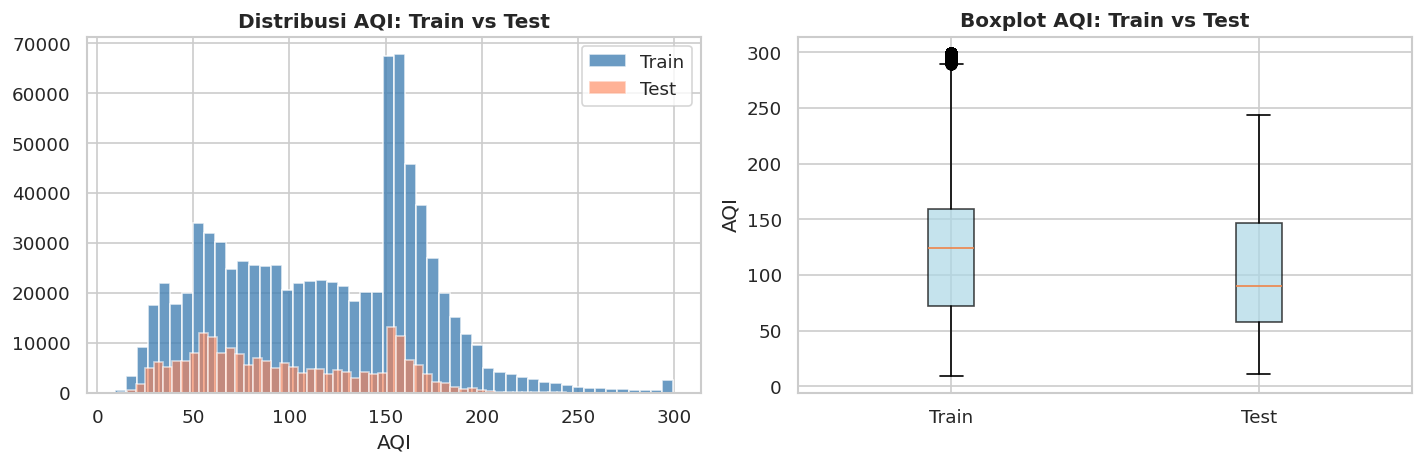

In [ ]:
print('=== VALIDASI AKHIR ===')
print(f'Missing value di X_train: {X_train_scaled.isnull().sum().sum()}')
print(f'Missing value di X_test : {X_test_scaled.isnull().sum().sum()}')
print(f'Missing value di y_train: {y_train.isnull().sum()}')
print(f'Missing value di y_test : {y_test.isnull().sum()}')

print(f'\n=== STATISTIK TARGET ===')
print(f'y_train - min: {y_train.min():.2f}, max: {y_train.max():.2f}, mean: {y_train.mean():.2f}')
print(f'y_test  - min: {y_test.min():.2f}, max: {y_test.max():.2f}, mean: {y_test.mean():.2f}')

# Distribusi target train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white', alpha=0.8, label='Train')
axes[0].hist(y_test,  bins=50, color='coral',     edgecolor='white', alpha=0.6, label='Test')
axes[0].set_title('Distribusi AQI: Train vs Test', fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].legend()

axes[1].boxplot([y_train, y_test], labels=['Train', 'Test'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_title('Boxplot AQI: Train vs Test', fontweight='bold')
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()

---
## 7. 💾 Export Data Siap Modelling

In [ ]:
import joblib

# === Simpan dataset ===
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv',        index=False)
y_test.to_csv('y_test.csv',          index=False)

# === Simpan scaler & encoder ===
joblib.dump(scaler,   'robust_scaler.pkl')
joblib.dump(le_city,  'label_encoder_city.pkl')

# === Simpan daftar fitur ===
import json
with open('feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET,
               'scale_cols': scale_cols, 'binary_cols': binary_cols}, f, indent=2)

print('✅ Semua file berhasil disimpan:')
print('   📄 X_train.csv, X_test.csv')
print('   📄 y_train.csv, y_test.csv')
print('   🔧 robust_scaler.pkl')
print('   🔧 label_encoder_city.pkl')
print('   📋 feature_list.json')

✅ Semua file berhasil disimpan:
   📄 X_train.csv, X_test.csv
   📄 y_train.csv, y_test.csv
   🔧 robust_scaler.pkl
   🔧 label_encoder_city.pkl
   📋 feature_list.json


In [ ]:
# === RINGKASAN PIPELINE ===
print('=' * 60)
print('📊 RINGKASAN PIPELINE PREPROCESSING')
print('=' * 60)
print(f'Dataset awal        : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'Dataset final train : {X_train_scaled.shape[0]:,} baris × {X_train_scaled.shape[1]} kolom')
print(f'Dataset final test  : {X_test_scaled.shape[0]:,} baris × {X_test_scaled.shape[1]} kolom')
print(f'Jumlah fitur        : {len(FEATURES)}')
print(f'Target              : {TARGET}')
print()
print('LANGKAH YANG DILAKUKAN:')
print('  1. ✅ Parse datetime & sort per kota')
print('  2. ✅ Hapus duplikasi (city_id + datetime)')
print('  3. ✅ Konversi nilai negatif → NaN')
print('  4. ✅ Winsorizing (1%-99%) per kota')
print('  5. ✅ Drop carbon_dioxide (>74% missing)')
print('  6. ✅ Drop baris AQI missing (target)')
print('  7. ✅ Interpolasi linear per kota (fitur)')
print('  8. ✅ Feature engineering temporal (cyclical)')
print('  9. ✅ Lag & rolling features (1,3,6,24 jam)')
print(' 10. ✅ Fitur interaksi polutan')
print(' 11. ✅ Label Encoding (city) + One-Hot (period, season)')
print(' 12. ✅ Time-aware split (80/20)')
print(' 13. ✅ RobustScaler (fit train only)')
print('=' * 60)
print('🚀 Data siap untuk modelling!')

📊 RINGKASAN PIPELINE PREPROCESSING
Dataset awal        : 1,048,551 baris × 13 kolom
Dataset final train : 837,708 baris × 104 kolom
Dataset final test  : 209,427 baris × 104 kolom
Jumlah fitur        : 104
Target              : aqi

LANGKAH YANG DILAKUKAN:
  1. ✅ Parse datetime & sort per kota
  2. ✅ Hapus duplikasi (city_id + datetime)
  3. ✅ Konversi nilai negatif → NaN
  4. ✅ Winsorizing (1%-99%) per kota
  5. ✅ Drop carbon_dioxide (>74% missing)
  6. ✅ Drop baris AQI missing (target)
  7. ✅ Interpolasi linear per kota (fitur)
  8. ✅ Feature engineering temporal (cyclical)
  9. ✅ Lag & rolling features (1,3,6,24 jam)
 10. ✅ Fitur interaksi polutan
 11. ✅ Label Encoding (city) + One-Hot (period, season)
 12. ✅ Time-aware split (80/20)
 13. ✅ RobustScaler (fit train only)
🚀 Data siap untuk modelling!
